# Deepfake Detection

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement or use deepfake detection methods
- Evaluate detection performance and limitations

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1, lesson 05 (the GAN) and Course 04 (AIAT 114) — Unit 3: detection is a classifier trained on the output of a generator you already know how to build.

**Used later in:** Course 10 — Unit 4, lesson 04, where detection and provenance become regulatory obligations.

---


# Deepfake Detection
## AIAT 124 - Generative AI

## Learning Objectives

- Understand deepfake generation
- Implement deepfake detection
- Use CNN for detection
- Apply to security and verification

## Real-World Context

Security, verification, and content authenticity.

**Industry Impact**: Critical for preventing misinformation and fraud.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: install and import PyTorch + torchvision.
# We need torch to build/train the GAN (fake maker) and the CNN detector (fake catcher),
# and torchvision for the MNIST dataset that plays the role of "real" images.
%pip install torch torchvision -q
import torch
import torch.nn as nn
print('✅ Setup complete!')

Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Part 1: Deepfake Detection Model

A deepfake detector is just a **binary image classifier**: input an image, output *real* or *fake*.
Below we define a small CNN detector for 28×28 grayscale images — later in this notebook we will
actually **train it and measure how well it detects** GAN-generated fakes.

In [2]:
# Define the deepfake detector: a small CNN that classifies an image as real or fake.
# Why a CNN? Generation artifacts (blur, checkerboard patterns, odd textures) are local
# pixel patterns — exactly what convolutional filters are good at picking up.
class DeepfakeDetector(nn.Module):
    """CNN-based real-vs-fake image classifier for 1x28x28 images."""
    def __init__(self):
        super().__init__()
        # Feature extractor: two conv blocks, each halving the spatial size (28 -> 14 -> 7)
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),   # 1 gray channel -> 16 feature maps
            nn.ReLU(), nn.MaxPool2d(2),        # downsample 28x28 -> 14x14
            nn.Conv2d(16, 32, 3, padding=1),  # 16 -> 32 feature maps
            nn.ReLU(), nn.MaxPool2d(2),        # downsample 14x14 -> 7x7
        )
        # Classifier head: flatten the feature maps and decide real (0) vs fake (1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(), nn.Dropout(0.3),        # dropout fights overfitting on our small set
            nn.Linear(64, 2)                   # 2 logits: [real, fake]
        )

    def forward(self, x):
        return self.classifier(self.features(x))

print('✅ Deepfake detector architecture defined')

✅ Deepfake detector architecture defined


## Part 2: Detection Techniques


In [3]:
# WHAT/WHY: name the four families of deepfake-detection methods before the
# hands-on artifact-based detector below.
print('📝 Deepfake Detection Methods:')
print('\n1. Frame-level Analysis: Check individual frames')
print('2. Temporal Analysis: Check consistency across frames')
print('3. Artifact Detection: Find generation artifacts')
print('4. Face Analysis: Check facial inconsistencies')
print('\n✅ Detection methods understood!')
print('\nReal-world applications:')
print('- Video verification')
print('- Social media content moderation')
print('- News authenticity checking')

📝 Deepfake Detection Methods:

1. Frame-level Analysis: Check individual frames
2. Temporal Analysis: Check consistency across frames
3. Artifact Detection: Find generation artifacts
4. Face Analysis: Check facial inconsistencies

✅ Detection methods understood!

Real-world applications:
- Video verification
- Social media content moderation
- News authenticity checking


## Real-World Applications

- **Security**: Identity verification
- **Media**: Content authenticity
- **Legal**: Evidence verification
- **Social Media**: Content moderation

## 🌍 Real-World Worked Example — Catching GAN Fakes

To *detect* fakes we first need fakes. **Step 1** below trains a small **fully-connected GAN**
(linear layers only — real DCGANs use convolutions) that generates handwritten-digit images from
pure noise. These play the role of "deepfakes" at MNIST scale.

**Step 2** (after it) trains our `DeepfakeDetector` CNN to tell the GAN's fakes apart from real
MNIST digits — and measures how well it does.

**Industry context:** deepfake detectors at Meta and Microsoft are trained the same way — on
datasets that mix real media with generated media — just at vastly larger scale.

Epoch 1/10 — D loss: 0.678  G loss: 1.527


Epoch 2/10 — D loss: 0.724  G loss: 1.704


Epoch 3/10 — D loss: 0.560  G loss: 3.035


Epoch 4/10 — D loss: 0.471  G loss: 2.929


Epoch 5/10 — D loss: 0.280  G loss: 3.017


Epoch 6/10 — D loss: 0.359  G loss: 2.719


Epoch 7/10 — D loss: 0.996  G loss: 5.652


Epoch 8/10 — D loss: 0.664  G loss: 2.155


Epoch 9/10 — D loss: 0.669  G loss: 2.707


Epoch 10/10 — D loss: 0.756  G loss: 1.615


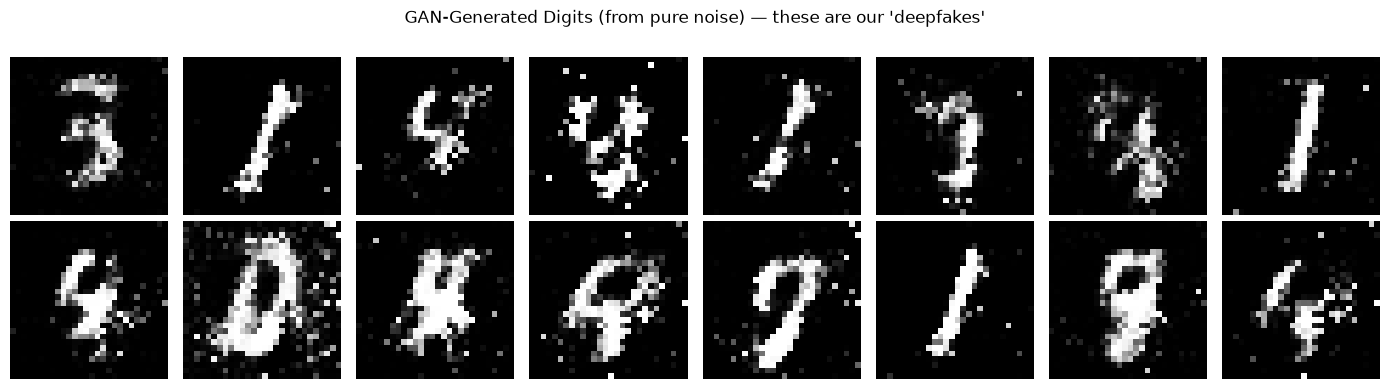

In [4]:
# Step 1 — train a small GAN so we have "fakes" to detect.
# Generator G maps random noise to a 28x28 image; discriminator D learns real-vs-fake;
# training alternates the two until G's samples start to look like digits.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

transform = T.Compose([T.ToTensor(), T.Normalize([0.5],[0.5])])
dataset   = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

# ── Generator: noise → image ───────────────────────────────────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
# ── Discriminator: image → real/fake ─────────────────────────────────────
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
bce   = nn.BCELoss()

d_losses, g_losses = [], []
for epoch in range(10):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        # ── Train Discriminator ─────────────────────────────────────────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()
        loss_D = bce(D(real_flat), torch.ones(bs,1)) + bce(D(fake), torch.zeros(bs,1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # ── Train Generator ─────────────────────────────────────────────
        z      = torch.randn(bs, LATENT_DIM)
        fake   = G(z)
        loss_G = bce(D(fake), torch.ones(bs,1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    d_losses.append(loss_D.item()); g_losses.append(loss_G.item())
    print(f"Epoch {epoch+1}/10 — D loss: {d_losses[-1]:.3f}  G loss: {g_losses[-1]:.3f}")

# ── Show generated images ──────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    samples = G(torch.randn(16, LATENT_DIM)).view(16, 28, 28).numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray'); ax.axis('off')
plt.suptitle("GAN-Generated Digits (from pure noise) — these are our 'deepfakes'")
plt.tight_layout(); plt.show()

## Part 3: Step 2 — Train the Detector and Measure Performance

We now build a labeled dataset: **real** MNIST digits (label 0) mixed with **fake** digits sampled
from the trained generator (label 1). We train the `DeepfakeDetector` CNN on one half and evaluate
on a held-out half — giving us an actual detection accuracy, not just an architecture diagram.

Epoch 1/2 — last batch loss: 0.3814


Epoch 2/2 — last batch loss: 0.1284

Detection accuracy on held-out set: 99.4%
  Real images correctly kept  : 98.9%
  Fake images correctly caught: 100.0%


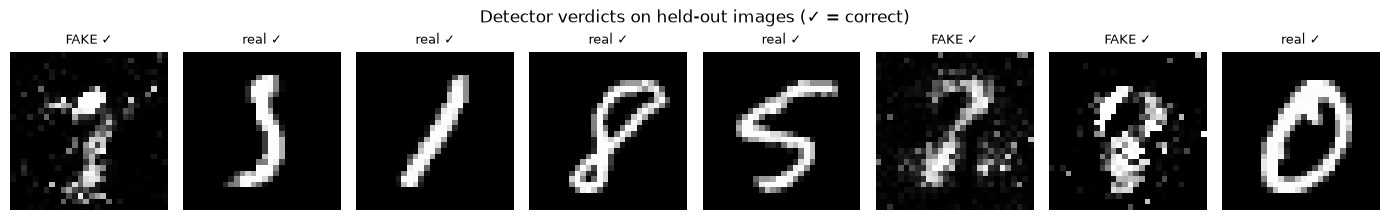

In [5]:
# Step 2 — train the CNN detector on real-vs-fake images and evaluate it.
# We deliberately hold out a test set so the reported accuracy is a real measurement.
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(0)
N_PER_CLASS = 3000  # 3000 real + 3000 fake images

# ── Build the dataset ──────────────────────────────────────────────────────
# Real digits: take MNIST images (already normalized to [-1,1], same range as G's Tanh output)
real_imgs = torch.stack([dataset[i][0] for i in range(N_PER_CLASS)])          # (N,1,28,28)
# Fake digits: sample the trained generator, reshape flat 784 -> image grid
with torch.no_grad():
    fake_imgs = G(torch.randn(N_PER_CLASS, LATENT_DIM)).view(-1, 1, 28, 28)
# Labels: real = 0, fake = 1
images = torch.cat([real_imgs, fake_imgs])
labels = torch.cat([torch.zeros(N_PER_CLASS, dtype=torch.long),
                    torch.ones(N_PER_CLASS, dtype=torch.long)])

# ── Split into train / test halves (shuffled) ─────────────────────────────
perm = torch.randperm(len(images))
images, labels = images[perm], labels[perm]
split = len(images) // 2
train_ds = TensorDataset(images[:split], labels[:split])
test_X, test_y = images[split:], labels[split:]
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

# ── Train the detector for 2 epochs ───────────────────────────────────────
detector = DeepfakeDetector()
opt  = optim.Adam(detector.parameters(), lr=1e-3)
lossf = nn.CrossEntropyLoss()
for epoch in range(2):
    detector.train()
    for xb, yb in train_loader:
        opt.zero_grad()
        loss = lossf(detector(xb), yb)
        loss.backward(); opt.step()
    print(f"Epoch {epoch+1}/2 — last batch loss: {loss.item():.4f}")

# ── Evaluate on the held-out half ─────────────────────────────────────────
detector.eval()
with torch.no_grad():
    pred = detector(test_X).argmax(1)
acc = (pred == test_y).float().mean().item()
# Per-class breakdown: how often reals and fakes are each caught correctly
real_acc = (pred[test_y == 0] == 0).float().mean().item()
fake_acc = (pred[test_y == 1] == 1).float().mean().item()
print(f"\nDetection accuracy on held-out set: {acc:.1%}")
print(f"  Real images correctly kept  : {real_acc:.1%}")
print(f"  Fake images correctly caught: {fake_acc:.1%}")

# ── Show a few test images with the detector's verdicts ───────────────────
fig, axes = plt.subplots(1, 8, figsize=(14, 2.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(test_X[i, 0].numpy(), cmap='gray'); ax.axis('off')
    verdict = 'FAKE' if pred[i] == 1 else 'real'
    correct = '✓' if pred[i] == test_y[i] else '✗'
    ax.set_title(f"{verdict} {correct}", fontsize=9)
plt.suptitle("Detector verdicts on held-out images (✓ = correct)")
plt.tight_layout(); plt.show()

### Reading the Result — and Its Limits

The accuracy above is high because our fully-connected GAN leaves **obvious artifacts** (blur,
noise texture) that the CNN spots easily. Two honest caveats that carry over to real deepfake work:

1. **Detectors overfit their generator.** This detector learned *this* GAN's artifacts; a fake from
   a different, better generator could slip through. Real benchmarks (e.g., Meta's Deepfake
   Detection Challenge) test on *unseen* generators — accuracy drops sharply.
2. **It's an arms race.** Better generators erase the artifacts detectors rely on, which is why
   provenance standards (watermarking, C2PA content credentials) complement detection.

## 📚 References & Further Reading

**Foundational Papers:**
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(the technology behind deepfakes)*
- Rössler et al. (2019) — [FaceForensics++: Learning to Detect Manipulated Facial Images](https://arxiv.org/abs/1901.08971) *(the standard deepfake-detection benchmark)*

**Recent:**
- Mirsky & Lee (2021) — [The Creation and Detection of Deepfakes: A Survey](https://arxiv.org/abs/2004.11138) *(ACM Computing Surveys)*
- Karras et al. (2020) — [StyleGAN2](https://arxiv.org/abs/1912.04958) *(the face generator behind "this person does not exist")*

**State-of-the-Art:** detectors still generalize poorly to unseen generators — detection is an arms race, which is why provenance standards (C2PA content credentials) are rising alongside classifiers.